In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [6]:
df_DA_INA = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DA_INA = df_DA_INA.dropna(subset='salary_year_avg')

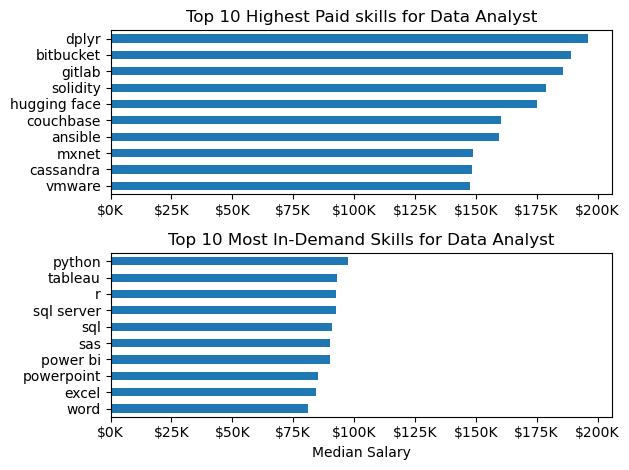

In [ ]:
df_DA_explode = df_DA_INA.explode('job_skills')

df_DA_top_pay = df_DA_explode.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False)
df_DA_top_pay = df_DA_top_pay.head(10)

df_DA_skills = df_DA_explode.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)
df_DA_skills = df_DA_skills.head(10).sort_values(by='median', ascending=False)


# plot using matplolib 

fig, ax = plt.subplots(2,1)

# top 10 highest paid skills for Data Analyst 
df_DA_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].set_title('Top 10 Highest Paid skills for Data Analyst')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

# top 10 Most Demand Skills for Data Analyst 
df_DA_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analyst')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary')
ax[1].set_xlim(ax[0].get_xlim()) #set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.tight_layout()
plt.show()

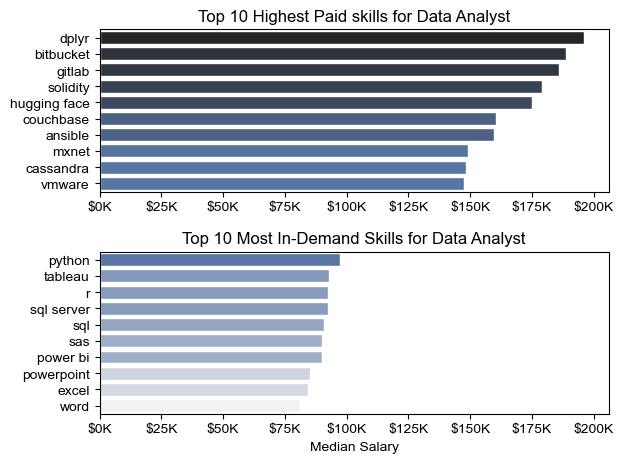

In [18]:
# create using seaborn 

fig, ax = plt.subplots(2,1)

sns.set_theme(style='ticks')

# top 10 highest paid skills for Data Analyst 

# df_DA_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False)
sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, ax=ax[0], hue='median', palette='dark:b_r') # b itu biru, _r itu reverse

ax[0].legend().remove()
ax[0].set_title('Top 10 Highest Paid skills for Data Analyst')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

# top 10 Most Demand Skills for Data Analyst 

# df_DA_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills.index, ax=ax[1], hue='median', palette='light:b')

ax[1].legend().remove()
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analyst')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary')
ax[1].set_xlim(ax[0].get_xlim()) #set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.tight_layout()
plt.show()

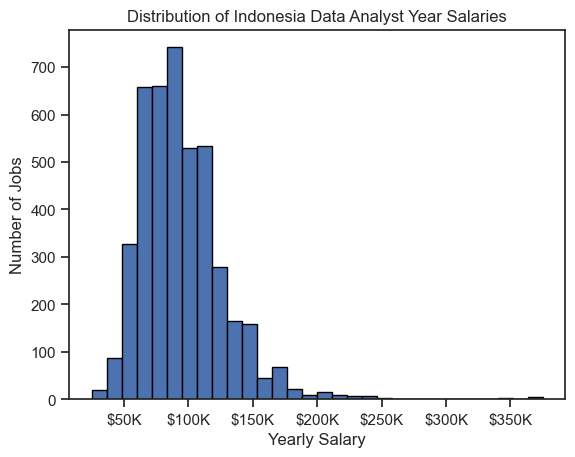

In [22]:
df_DA_INA['salary_year_avg'].plot(kind='hist', bins=30, edgecolor='black')

plt.title('Distribution of Indonesia Data Analyst Year Salaries')
plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.show()

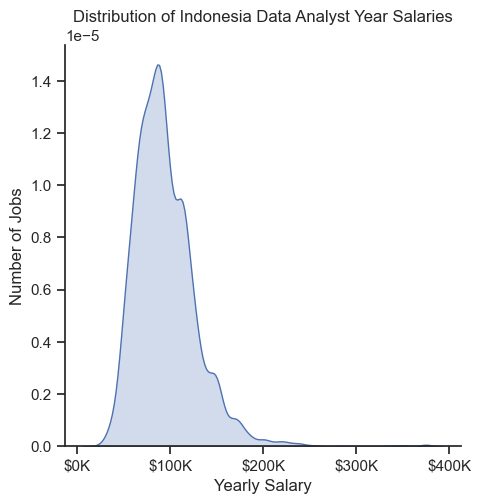

In [ ]:
# histogram using seaborn

sns.displot(df_DA_INA['salary_year_avg'], kind='kde', fill=True)

plt.title('Distribution of Indonesia Data Analyst Year Salaries')
plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.show()

C:\Users\Fathur Zhafran\AppData\Local\Temp\ipykernel_10876\2479568195.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


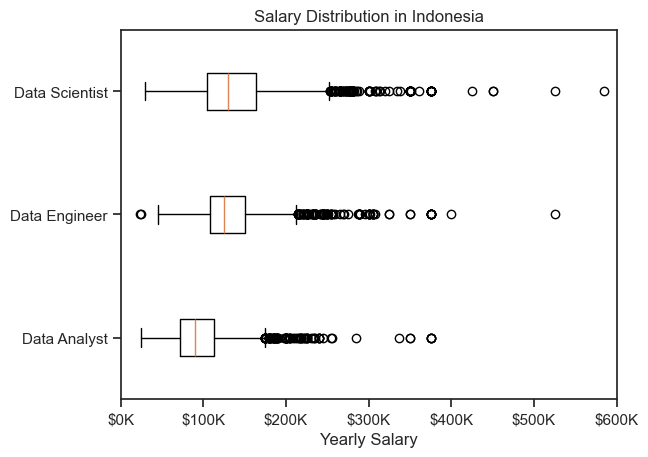

In [31]:
# box plot using matplotlib 
# plt.boxplot(job_list, labels=job_titles, vert=False)

# create job titles 
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

# filter for job tilte in job titles above 
df_INA = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()

# drop the nan value 
df_INA = df_INA.dropna(subset=['salary_year_avg'])

# create job list using for loop
job_list = [df_INA[df_INA['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, labels=job_titles, vert=False)
plt.title('Salary Distribution in Indonesia')
plt.xlabel('Yearly Salary')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
plt.xlim(0,600000)
plt.show()

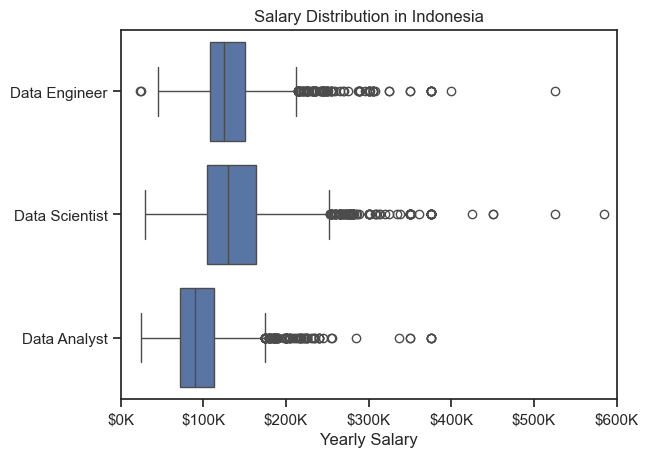

In [30]:
# box plot using seaborn

sns.boxplot(data=df_INA, x='salary_year_avg', y='job_title_short')
plt.title('Salary Distribution in Indonesia')
plt.xlabel('Yearly Salary')
plt.ylabel('')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
plt.xlim(0,600000)
plt.show()